# Calibrating simulated frame sensor sizing for robust fit within WAC footprints

Goal: one fixed pinhole sensor model -- isotropic focal length, principal point exactly at image
center (`cu = cv = image_size / 2`) -- that reliably renders inside real WAC crop footprints across
"nominal" EDRs, plus an off-nadir threshold for rejecting non-nominal ones before dataset
generation. Per-EDR ground truth here (a real crop's own footprint corners, and the focal length a
symmetric FOV needs to just cover them) comes from this project's existing camera-pose pipeline; this
notebook only asks what size and shape the *fixed* model should be, not how that pipeline works.

Two geometric quantities matter, and they aren't coupled the way "off-nadir angle" alone would
suggest:
- **Size** -- the focal length needed to keep a render inside a crop's along-track extent -- tracks
  altitude, not off-nadir angle.
- **Near/far asymmetry** -- how far a crop's own footprint extends fore vs. aft of the boresight --
  tracks the *along-track* component of off-nadir tilt. Under a centered principal point, the
  *cross-track* component doesn't produce this kind of asymmetry; it only changes how much of the
  fixed focal length's own margin goes unused.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import trntest
from trntest import camera, spice_kernels
from trntest.config import MOON_RADIUS_KM

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
image_size = session.config.image_size

print(f"{len(dataset)} manifest rows")

81 manifest rows


## Cheap, ISIS-free geometry sweep

For every manifest row: altitude, slant range, total off-nadir angle, and its along-track/
cross-track decomposition (`camera.off_nadir_tilt_components_deg`) -- pure SPICE, no ISIS, so this
covers the whole manifest in seconds regardless of which entries have been populated.

In [2]:
rows = []
for entry in dataset:
    row = entry.row
    frame_timing = entry.frame_timing
    per_image_config = entry.per_image_config
    spice_kernels.fetch_and_furnish(frame_timing.start_time, per_image_config)

    center_frame_index = row["center_frame_index"]
    et = camera.frame_et(frame_timing, center_frame_index)
    c_m, r_cam_to_me, slant_range_km, off_nadir_deg = camera.camera_pose_moon_me(et)
    forward_step_km = camera.ground_track_step_km(frame_timing, center_frame_index)
    tilt_along_deg, tilt_cross_deg = camera.off_nadir_tilt_components_deg(c_m / 1000.0, r_cam_to_me, forward_step_km)

    rows.append(
        dict(
            product_id=entry.product_id,
            center_lat_deg=row["center_lat_deg"],
            altitude_km=np.linalg.norm(c_m / 1000.0) - MOON_RADIUS_KM,
            slant_range_km=slant_range_km,
            off_nadir_deg=off_nadir_deg,
            tilt_along_deg=tilt_along_deg,
            tilt_cross_deg=tilt_cross_deg,
            n_frames_for_square_crop=row["n_frames_for_square_crop"],
        )
    )

geometry_df = pd.DataFrame(rows)
geometry_df.describe()

,center_lat_deg,altitude_km,slant_range_km,off_nadir_deg,tilt_along_deg,tilt_cross_deg,n_frames_for_square_crop
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,5.379038,108.353046,108.472747,1.531936,1.080749,0.089624,70.913580
std,50.264209,21.169597,21.106033,2.321959,0.368222,2.540345,3.695259
min,-68.235000,73.143949,73.158142,1.102563,-1.424222,-3.476246,65.000000
25%,-46.978100,85.419662,85.506619,1.106059,1.084112,-0.221438,68.000000
50%,8.336300,116.730315,116.753587,1.107860,1.085598,-0.219642,71.000000
75%,53.722000,127.620984,127.646514,1.110741,1.087678,-0.217981,72.000000
max,73.248300,130.408054,130.434157,17.416788,3.092042,17.365300,78.000000


## Where the variation actually lives

Left: footprint size (`n_frames_for_square_crop`) tracks altitude, which tracks latitude through
LRO's eccentric, near-polar orbit -- not a curvature effect (a few-degree FOV over ~100 km is far
too small for the Moon's own shape to matter), an orbital-mechanics one. Right: off-nadir tilt is
almost entirely a cross-track effect -- `tilt_along_deg` sits in a narrow band across nearly every
row, while `tilt_cross_deg` is what separates the outliers.

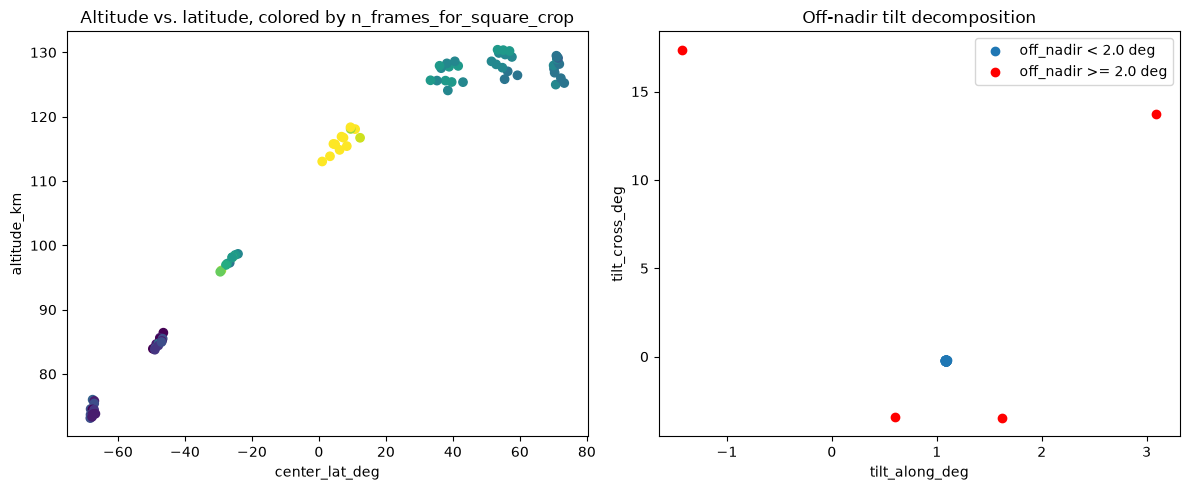

In [3]:
TIGHT_CLUSTER_DEG = 2.0  # marks the visual gap below, not yet the adopted threshold -- see below

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(geometry_df["center_lat_deg"], geometry_df["altitude_km"], c=geometry_df["n_frames_for_square_crop"])
axes[0].set_xlabel("center_lat_deg")
axes[0].set_ylabel("altitude_km")
axes[0].set_title("Altitude vs. latitude, colored by n_frames_for_square_crop")

nominal = geometry_df["off_nadir_deg"] < TIGHT_CLUSTER_DEG
axes[1].scatter(
    geometry_df.loc[nominal, "tilt_along_deg"],
    geometry_df.loc[nominal, "tilt_cross_deg"],
    label=f"off_nadir < {TIGHT_CLUSTER_DEG} deg",
)
axes[1].scatter(
    geometry_df.loc[~nominal, "tilt_along_deg"],
    geometry_df.loc[~nominal, "tilt_cross_deg"],
    color="red",
    label=f"off_nadir >= {TIGHT_CLUSTER_DEG} deg",
)
axes[1].set_xlabel("tilt_along_deg")
axes[1].set_ylabel("tilt_cross_deg")
axes[1].set_title("Off-nadir tilt decomposition")
axes[1].legend()
plt.tight_layout()

## The gap in the data

`off_nadir_deg` separates the manifest into a tight cluster under ~1.15 deg and 4 outliers, with
nothing in between until 3.47 deg -- and a second, much larger gap after that, up to 14.03 deg.
`off_nadir_deg < 2` sits in the first gap; it's not yet clear whether it's the *right* place to cut,
or just *a* defensible one. The two outliers just past it (3.47, 3.84 deg) might be cheap to keep.

In [4]:
outliers = geometry_df[geometry_df["off_nadir_deg"] >= TIGHT_CLUSTER_DEG].sort_values("off_nadir_deg", ascending=False)
print(f"{len(outliers)} of {len(geometry_df)} rows exceed off_nadir_deg >= {TIGHT_CLUSTER_DEG}:")
outliers[["product_id", "center_lat_deg", "off_nadir_deg", "tilt_along_deg", "tilt_cross_deg"]]

4 of 81 rows exceed off_nadir_deg >= 2.0:


,product_id,center_lat_deg,off_nadir_deg,tilt_along_deg,tilt_cross_deg
51,M1327265552CE,-29.1023,17.416788,-1.424222,17.365300
43,M1327258213CE,-47.8313,14.026818,3.092042,13.707650
30,M1327244120CE,-49.5604,3.835090,1.623742,-3.476246
37,M1327251520CE,-24.9840,3.467387,0.602358,-3.414917


## Sensor size across the tight cluster

`entry.camera`'s real, ISIS-derived `fu` for one candidate per altitude band identified above, all
inside the tight cluster and already crop-cached from prior work, to keep this fast. `fu` doesn't
depend on where `cv` ends up -- it's set purely by how many pixels are needed to span a crop's own
near+far along-track extent -- so this is meaningful on its own, before deciding anything about `cv`.

In [5]:
tight_sample_ids = [
    "M1327222602CE",  # ~-67 deg lat, low-altitude band
    "M1327223032CE",  # ~-47 deg lat
    "M1327223360CE",  # ~-27 deg lat
    "M1327223847CE",  # ~8 deg lat, peak n_frames_for_square_crop
    "M1327218124CE",  # ~59 deg lat, high-altitude band
]
entries = {pid: dataset[pid] for pid in tight_sample_ids}


def required_fu(product_id: str) -> float:
    return entries[product_id].camera.focal_length_u_px


tight_fu = pd.Series({pid: required_fu(pid) for pid in tight_sample_ids}, name="fu")
print(tight_fu)
recommended_f_tight = tight_fu.max()
print(f"\nrecommended_f (tight cluster only) = {recommended_f_tight:.2f}")

M1327222602CE    1282.703889
M1327223032CE    1285.440540
M1327223360CE    1291.667464
M1327223847CE    1286.075191
M1327218124CE    1269.417572
Name: fu, dtype: float64

recommended_f (tight cluster only) = 1291.67


## Centered principal point: does it fit?

Take `fu = fv = recommended_f_tight` and `cu = cv = image_size / 2` -- the target design -- and
check each tight-cluster candidate's own real crop footprint (near/far along-track extent, via
`camera.along_track_extent_km`) against what this camera's own footprint (`camera.footprint_lonlat`)
actually reaches. A positive margin means the render lands inside the real crop on that side; negative
means it overshoots.

In [6]:
def margins_km(product_id: str, f: float, cv: float) -> tuple[float, float]:
    entry = entries[product_id]
    cam = entry.camera
    c_km = np.array(cam.camera_center_moon_me_m) / 1000.0
    r_cam_to_me = np.array(cam.r_cam_to_me)
    along_track_axis_me = np.array(cam.camera_along_track_direction_moon_me)
    boresight_ground_km = camera.boresight_ground_point_km(c_km, r_cam_to_me)
    target_near_km, target_far_km = camera.along_track_extent_km(
        entry.crop_footprint, boresight_ground_km, along_track_axis_me
    )
    footprint = camera.footprint_lonlat(c_km, r_cam_to_me, f, f, image_size / 2.0, cv, image_size)
    achieved_near_km, achieved_far_km = camera.along_track_extent_km(
        footprint, boresight_ground_km, along_track_axis_me
    )
    return target_near_km - achieved_near_km, target_far_km - achieved_far_km


def centered_margins_km(product_id: str, f: float) -> tuple[float, float]:
    return margins_km(product_id, f, image_size / 2.0)


tight_margins = pd.DataFrame(
    [
        dict(product_id=pid, near_margin_km=n, far_margin_km=f)
        for pid, (n, f) in ((pid, centered_margins_km(pid, recommended_f_tight)) for pid in tight_sample_ids)
    ]
)
tight_margins

,product_id,near_margin_km,far_margin_km
0,M1327222602CE,4.905853,1.228419
1,M1327223032CE,5.496784,1.234768
2,M1327223360CE,5.884314,1.313820
3,M1327223847CE,7.226973,1.966726
4,M1327218124CE,8.848723,3.240176


Every margin is comfortably positive -- a centered principal point fits the tight cluster with room
to spare. That's the working assumption for the rest of this notebook; the question from here is how
far it can be pushed before it stops holding.

## What would keeping each outlier cost?

Each outlier's own required `fu`, and its centered-principal-point margins at whatever shared `f`
the resulting sample needs -- to see whether admitting an outlier costs a little unused margin
(fine) or breaks the centered assumption outright (not fine).

In [7]:
outlier_ids = list(outliers["product_id"])
entries.update({pid: dataset[pid] for pid in outlier_ids})
outlier_fu = pd.Series({pid: entries[pid].camera.focal_length_u_px for pid in outlier_ids}, name="fu")
print(f"Outlier fu vs. tight cluster range ({tight_fu.min():.1f} - {tight_fu.max():.1f}):")
print(outlier_fu.to_string())

moderate_ids = ["M1327244120CE", "M1327251520CE"]
extreme_ids = ["M1327258213CE", "M1327265552CE"]

recommended_f = pd.concat([tight_fu, outlier_fu.loc[moderate_ids]]).max()
print(f"\nrecommended_f (tight cluster + moderate outliers) = {recommended_f:.2f}")

Outlier fu vs. tight cluster range (1269.4 - 1291.7):
M1327265552CE    1209.316999
M1327258213CE    1209.316999
M1327244120CE    1342.522354
M1327251520CE    1321.372214

recommended_f (tight cluster + moderate outliers) = 1342.52


In [8]:
cost_rows = []
for pid in tight_sample_ids + moderate_ids + extreme_ids:
    near_km, far_km = centered_margins_km(pid, recommended_f)
    cost_rows.append(
        dict(
            product_id=pid,
            group="tight" if pid in tight_sample_ids else ("moderate" if pid in moderate_ids else "extreme"),
            near_margin_km=near_km,
            far_margin_km=far_km,
        )
    )
cost_df = pd.DataFrame(cost_rows)
cost_df

,product_id,group,near_margin_km,far_margin_km
0,M1327222602CE,tight,6.235078,3.003871
1,M1327223032CE,tight,7.004867,3.248622
2,M1327223360CE,tight,7.613973,3.599758
3,M1327223847CE,tight,9.298695,4.697082
4,M1327218124CE,tight,11.151926,6.204222
5,M1327244120CE,moderate,6.568506,2.726996
6,M1327251520CE,moderate,8.461039,4.041973
7,M1327258213CE,extreme,5.023077,-2.176969
8,M1327265552CE,extreme,7.051982,2.255898


The two moderate outliers need `fu` up to ~1345 -- about 4% above the tight cluster's own max
(~1292) -- and at that shared, larger `f` their own centered margins come out comparable to the
tight cluster's own range (one far margin lands just under it, ~2.7 km vs. a ~3.0 km floor -- not a
meaningful difference). Cheap to keep.

The two extreme outliers are a different story at that same `f`: one (`M1327258213CE`) comes out
**negative** on its far margin -- an actual coverage failure, not just reduced margin. The other
(`M1327265552CE`) stays positive but thinner than every tight-cluster candidate's own margin. Neither
fits the centered-principal-point premise the way the rest of the manifest does -- this is the
along-track-tilt-driven asymmetry breaking down once cross-track tilt (which a centered `cu` never
corrects for) gets large enough to distort the along-track corners too, not a small stretch of an
otherwise-fine fit. Keeping literally every row would mean carrying these two anyway, past
`off_nadir_deg = 17.42` -- nowhere near "~5 deg", and not just a wider margin.

**`THRESHOLD_DEG = 5.0`**: keeps the two moderate outliers (comfortably past their 3.84 deg, with
room before the 14.03 deg jump), excludes the two extreme ones.

In [9]:
THRESHOLD_DEG = 5.0
sample_product_ids = tight_sample_ids + moderate_ids
print(f"THRESHOLD_DEG = {THRESHOLD_DEG}")
print(f"fu = fv = {recommended_f:.2f}")
print(f"cu = cv = {image_size / 2.0:.2f}")

THRESHOLD_DEG = 5.0
fu = fv = 1342.52
cu = cv = 658.00


## Side experiment: does letting `cv` float buy anything?

`camera.solve_corrected_fov` (today's per-EDR machinery) doesn't center `cv` -- it shifts it to
balance near/far margins exactly, using up whatever slack a shared `f` leaves. Given the centered
margins above are already comfortably positive for every kept candidate, is a fitted `cv` worth the
extra per-EDR complexity? Compare both variants directly, across the final 7-candidate sample.

In [10]:
fit_cv = (
    image_size / 2.0
    + pd.Series({pid: entries[pid].camera.principal_point_v_px - image_size / 2.0 for pid in sample_product_ids}).mean()
)

side_rows = []
for pid in sample_product_ids:
    for label, cv in [("fit", fit_cv), ("centered", image_size / 2.0)]:
        near_km, far_km = margins_km(pid, recommended_f, cv)
        side_rows.append(dict(product_id=pid, cv_variant=label, near_margin_km=near_km, far_margin_km=far_km))

side_df = pd.DataFrame(side_rows)
side_df.pivot(index="product_id", columns="cv_variant", values=["near_margin_km", "far_margin_km"])

near_margin_km           far_margin_km          
cv_variant          centered       fit      centered       fit
product_id                                                    
M1327218124CE      11.151926  8.444828      6.204222  9.649935
M1327222602CE       6.235078  4.661356      3.003871  5.085573
M1327223032CE       7.004867  5.221868      3.248622  5.605418
M1327223360CE       7.613973  5.572398      3.599758  6.269851
M1327223847CE       9.298695  6.859734      4.697082  7.875350
M1327244120CE       6.568506  4.796037      2.726996  5.007059
M1327251520CE       8.461039  6.362582      4.041973  6.710717

Fitting `cv` shifts slack from the far side to the near side -- expected, since moving `cv` away
from the near edge gives it more room and takes room from the far edge -- but every margin stays
positive either way, on this sample. Fitting buys back a bit of otherwise-unused margin, not
coverage. Not worth the per-EDR complexity for a sensor model that's supposed to be simple and fixed.

## Recommendation

**Rejection criterion**: exclude any EDR with `off_nadir_deg >= 5.0` before generating a
`hillshade`/`reproject` pair from it.

**Fixed sensor parameters** (at `image_size` pixels, isotropic, centered principal point):

In [11]:
print(f"THRESHOLD_DEG = {THRESHOLD_DEG}")
print(f"image_size = {image_size}")
print(f"fu = fv = {recommended_f:.2f}")
print(f"cu = cv = {image_size / 2.0:.2f}")

THRESHOLD_DEG = 5.0
image_size = 1316
fu = fv = 1342.52
cu = cv = 658.00
